This notebook will plot profiles of aerosol mass from Thompson and Morrison, in order to show in the review responses that Morrison has higher aerosol loading that what the surface data suggests in Figure A1.

In [1]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import re

# Read model data

In [2]:
mosaic_nav = xr.open_dataset("/mnt/data/mosaic/nav/mosaic_coords_2020-04.nc")
mosaic_nav = mosaic_nav.assign_coords({"day": ("time", [T.dt.day for T in mosaic_nav.time])})

simulations = {
    "ACI_OPT_2": {
        "microphysics": "Thompson",
        "pollution_state": "polluted",
    },
    "ACI_OPT_2_NO_ANTHRO_NO_FIRES": {
        "microphysics": "Thompson",
        "pollution_state": "clean",
    },
    "MORR2MOM": {
        "microphysics": "Morrison",
        "pollution_state": "polluted",
    },
    "MORR2MOM_NO_ANTHRO_NO_FIRES": {
        "microphysics": "Morrison",
        "pollution_state": "clean",
    },
}

wrfout = []

for sim,meta in simulations.items():
    print(sim)
    fnames = glob.glob(f"/mnt/data/model_output/{sim}/*_mosaic.nc")
    if not fnames:
        continue
    with xr.open_mfdataset(fnames).load() as sim_data:
        sim_data = sim_data.expand_dims({
            "simulation": [sim]
        })
        sim_data = sim_data.assign_coords({
            "pollution_state": ("simulation",[meta["pollution_state"]]),
            "longitude": (["south_north","west_east"],sim_data.XLONG.isel(Time=0).values),
            "latitude": (["south_north","west_east"],sim_data.XLAT.isel(Time=0).values),
        })
        wrfout.append(sim_data)
wrfout = xr.concat(wrfout, dim="simulation")
wrfout["rho_air"] = wrfout.wrf.density_of_dry_air[:]
wrfout["air_temperature"] = wrfout.wrf.air_temperature[:]
wrfout["altitude"] = wrfout.wrf.altitude_asl_c[:]


ACI_OPT_2


/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  with xr.open_mfdataset(fnames).load() as sim_data:
/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  with xr.open_mfdataset(fnames).load() as sim_data:
/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of

ACI_OPT_2_NO_ANTHRO_NO_FIRES


/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  with xr.open_mfdataset(fnames).load() as sim_data:
/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  with xr.open_mfdataset(fnames).load() as sim_data:
/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of

MORR2MOM


/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  with xr.open_mfdataset(fnames).load() as sim_data:
/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  with xr.open_mfdataset(fnames).load() as sim_data:
/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of

MORR2MOM_NO_ANTHRO_NO_FIRES


/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  with xr.open_mfdataset(fnames).load() as sim_data:
/tmp/ipykernel_49568/3594994088.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  with xr.open_mfdataset(fnames).load() as sim_data:


In [3]:
def make_bin_dimension(ds_wrf, species, nbins=4):
    aname, cwname = species+"_a", species+"_cw"

    # convert a0X output for this species to one array with new bin dimension
    aer_vars = [v for v in ds_wrf.data_vars if aname in v.lower()]
    array_aer = ds_wrf[aer_vars].to_array(dim="bin")
    array_aer["bin"] = np.arange(nbins)

    # cw0X variables
    cld_vars = [v for v in ds_wrf.data_vars if cwname in v.lower()]
    array_cld = ds_wrf[cld_vars].to_array(dim="bin")
    array_cld["bin"] = np.arange(nbins)

    # add new variables to new dataset
    ds_binned = xr.Dataset()
    ds_binned[species] = array_aer+array_cld

    # add bin size coordinates for new dimension
    [dlo, dmid, dhi] = utils.calc_mosaic_size_bins()    
    ds_binned = ds_binned.assign_coords({
        "Dlo": ("bin", dlo),
        "Dmid": ("bin", dmid),
        "Dhi": ("bin", dhi),
        "dD": ("bin", dhi-dlo)
    })

    return ds_binned

def sum_wrf_aero_bins(ds_binned, cutoff=1):
    if "bin" not in ds_binned.dims:
        msg = "[sum_wrf ERROR] no bin dimension on the dataset"
        raise ValueError(msg)
        return
    nbins = len(ds_binned.bin)
    bin_bounds = np.zeros((nbins+1))
    bin_bounds[:-1] = ds_binned.Dlo.values
    bin_bounds[-1] = ds_binned.Dhi.values[-1]

    # find size bin containing cutoff
    i = np.searchsorted(bin_bounds, cutoff)-1

    # sum up to cutoff
    ds_sum = ds_binned.isel(bin=slice(None,i)).sum(dim="bin")

    # add linear fraction of bin containing cutoff
    ibin_width = ds_binned.Dhi.values[i] - ds_binned.Dlo.values[i]
    f = (cutoff - ds_binned.Dlo.values[i]) / ibin_width
    ds_sum += f*ds_binned.isel(bin=i, drop=True)
    
    return ds_sum



In [4]:
wrfout["so4"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "so4")).so4
wrfout["bc"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "bc")).bc
wrfout["oc"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "oc")).oc
wrfout["toa"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "totoa")).totoa


In [5]:
wrfout_mosaic_mean = wrfout.mean(["i","j"])
wrfout_mosaic_min = wrfout.min(["i","j"])
wrfout_mosaic_max = wrfout.max(["i","j"])
wrfout_mosaic_ctr = wrfout.isel(i=1, j=1)


In [6]:
def interp_1d(height, var, height_new):
    return np.interp(height_new, height, var)

def interp_zdim(ds, da_height_new):
    vars_to_interp = [v for v in ds.data_vars if v not in ["altitude","PH","PHB"]]
    ds_interp = xr.Dataset()
    da_height_old = ds["altitude"].drop_attrs()
    for var in vars_to_interp:
        if "bottom_top" not in ds[var].dims:
            print(f"skipping {var} with no height coordinate")
            continue
        ds_interp[var] = xr.apply_ufunc(
            interp_1d,
            da_height_old,         # first arg: height profile
            ds[var],              # second arg: variable profile
            da_height_new,        # third arg: target heights
            input_core_dims=[["bottom_top"],["bottom_top"],["bottom_top"]],
            output_core_dims=[["bottom_top"]],
            vectorize=True,           # loop automatically over (sim, time)
            dask="parallelized",      # works with dask arrays
            keep_attrs="no_conflicts"
        )
    # add new height coordinate
    ds_interp = ds_interp.assign_coords({
        'height': (['bottom_top'], da_height_new.data)
    })
    return ds_interp

In [7]:
wrfout_profiles = []
for s,sim in enumerate(simulations):
    ds = wrfout_mosaic_mean.sel(simulation=sim)
    wrfout_profiles.append(interp_zdim(
        ds,
        ds.altitude.mean("Time", keep_attrs=False)
    ))
wrfout_profiles = xr.concat(wrfout_profiles, dim="simulation")



skipping SWUPB with no height coordinate
skipping LWUPB with no height coordinate
skipping LWDNB with no height coordinate
skipping SWDNB with no height coordinate
skipping SWUPB with no height coordinate
skipping LWUPB with no height coordinate
skipping LWDNB with no height coordinate
skipping SWDNB with no height coordinate
skipping SWUPB with no height coordinate
skipping LWUPB with no height coordinate
skipping LWDNB with no height coordinate
skipping SWDNB with no height coordinate
skipping SWUPB with no height coordinate
skipping LWUPB with no height coordinate
skipping LWDNB with no height coordinate
skipping SWDNB with no height coordinate


/tmp/ipykernel_49568/784195994.py:8: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  wrfout_profiles = xr.concat(wrfout_profiles, dim="simulation")


# Plot aerosol vertical profiles

In [8]:
matplotlib.rcParams["font.size"] = 16.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2


In [9]:
c = {
    "Thompson": "tab:red",
    "Morrison": "tab:blue"
}

ls = {
    "polluted": "solid",
    "clean": "dashed"
}

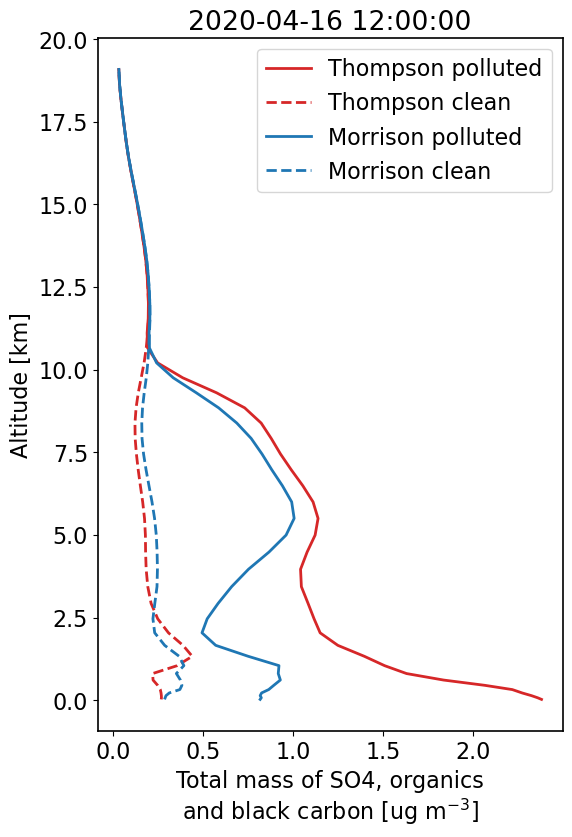

In [14]:
time = dt.datetime(2020,4,16,12)

fig = plt.figure(figsize=(6,9))
for s,sim in enumerate(simulations):
    profile = wrfout_profiles.sel(simulation=sim, Time=time)
    plt.plot(
        (profile.bc+profile.oc+profile.toa+profile.so4),
        profile.height/1000,
        c=c[simulations[sim]["microphysics"]],
        ls=ls[simulations[sim]["pollution_state"]],
        label=f"{simulations[sim]['microphysics']} {simulations[sim]['pollution_state']}"
    )

plt.legend()
plt.xlabel("Total mass of SO4, organics\nand black carbon [ug m$^{{-3}}$]")
plt.ylabel("Altitude [km]")
plt.title(time)
plt.savefig("../figures/figureA3.png", bbox_inches="tight")
